# TD n°2
Comparaison de classifieurs linéaires et non-linéaires sur un jeu de données réel

In [1]:
%matplotlib inline

##  On commence par importer des modules basique Python
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib as mpl

from sklearn import datasets

In [3]:
#data = datasets.load_wine()
data = datasets.load_breast_cancer()
#data=datasets.load_digits()

X=data.data
y=data.target

##  Pour les digits, si on veut se restreint aux classes 8 and 6
#X=X[(y==6)+(y==8),:]
#y=y[(y==6)+(y==8)]
##  Si on veut afficher un exemple :
#plt.imshow(np.reshape(X[1,:],(8,8)), cmap='gray')

n_class = np.unique(y).shape[0]
y = (y-np.min(y) / (n_class) ).astype('int')

print('Taille du jeu de données : ')
print(X.shape)
print('Classes distincts :')
print(np.unique(y))

Taille du jeu de données : 
(569, 30)
Classes distincts :
[0 1]


## Questions
* **En utilisant sklearn**, centrer/réduire - blanchir les données

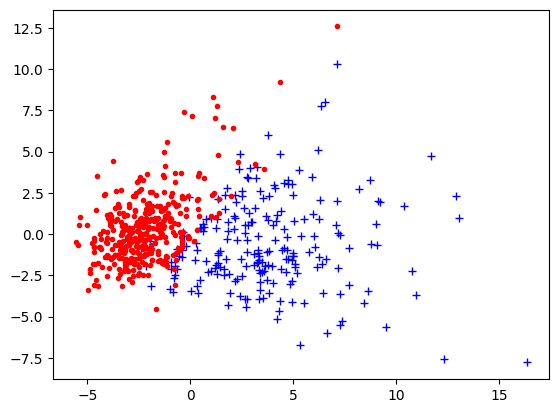

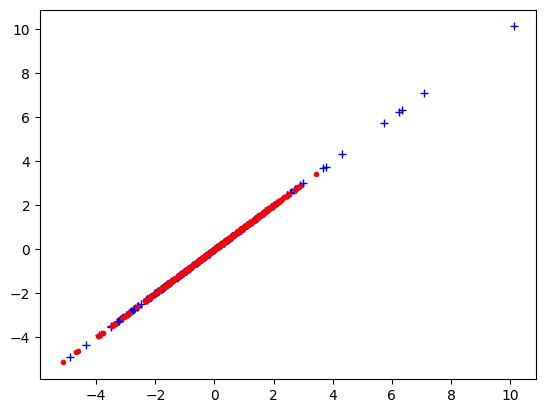

In [10]:
# CODE MANQUANT
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Centrage et reducation "à la sklearn"
stdScale = StandardScaler()
X = stdScale.fit_transform(X)

# Analyse en composantes principales (ACP) "à la sklearn"
pca = PCA(n_components=4)
X = pca.fit_transform(X)

plt.figure(1)
plt.plot(X[y==0,0] , X[y==0,1] , 'b+')
plt.plot(X[y==1,0] , X[y==1,1] , 'r.')

plt.figure(2)
plt.plot(X[y==0,2] , X[y==0,2] , 'b+')
plt.plot(X[y==1,3] , X[y==1,3] , 'r.')


## Questions
* **En utilisant sklearn**, faire une validation croisée (k-fold, en anglais) à $k=10$ plis

In [12]:
# CODE MANQUANT
from sklearn.model_selection import KFold
kf = KFold(n_splits=10)
kf_splits = kf.split(X)

for idx_train , idx_test in kf_splits:
#    print('Taille du jeu de données : Train=' + str(idx_train.shape[0]) + ' / Test=' +str(idx_test.shape[0]) )
    X_train = X[idx_train,:]
    X_test = X[idx_test,:]
    y_train = y[idx_train]
    y_test = y[idx_test]
    print('Taille du jeu de données : Train=' + str(X_train.shape) + ' / Test=' +str(X_test.shape) )




Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(512, 4) / Test=(57, 4)
Taille du jeu de données : Train=(513, 4) / Test=(56, 4)


## Questions
* **En utilisant sklearn**, implémenter entraîner les trois classifieurs linéaires différents que sont le LASSO, le SVM linéaire, et la régression Ridge
* moyenner les résultats (taux d'erreurs, bonne classification ...) sur les $k=10$ plis

In [17]:
# CODE MANQUANT

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import Lasso
from sklearn.svm import LinearSVC
clfRidge = RidgeClassifier()
clfLasso = Lasso()
clfSVM = LinearSVC()

from sklearn.model_selection import KFold
kf = KFold(n_splits=10)
kf_splits = kf.split(X)

#avec la fonction cross_val_score
from sklearn.model_selection import cross_val_score
scoresRidge = cross_val_score(clfRidge, X, y, cv=kf_splits)
kf_splits = kf.split(X)
scoresLasso = cross_val_score(clfLasso, X, y, cv=kf_splits)
kf_splits = kf.split(X)
scoresSVM = cross_val_score(clfSVM, X, y, cv=kf_splits)

print('Score du classifieur Ridge = ' + str(np.mean(scoresRidge)))
print('Score du classifieur Lasso = ' + str(np.mean(scoresLasso)))
print('Score du classifieur SVM = ' + str(np.mean(scoresSVM)))

# "à la main" avec la fonction kf.split
NbErreurRidge = 0
NbErreurLasso = 0
NbErreurSVM = 0

kf_splits = kf.split(X)
for idx_train , idx_test in kf_splits:
#    print('Taille du jeu de données : Train=' + str(idx_train.shape[0]) + ' / Test=' +str(idx_test.shape[0]) )
    X_train = X[idx_train,:]
    X_test = X[idx_test,:]
    y_train = y[idx_train]
    y_test = y[idx_test]
#    print('Taille du jeu de données : Train=' + str(X_train.shape) + ' / Test=' +str(X_test.shape) )
    clfRidge.fit(X_train, y_train)
    y_ridge = clfRidge.predict(X_test)
    NbErreurRidge += np.sum(y_ridge != y_test)

    clfLasso.fit(X_train, y_train)
    y_lasso = clfLasso.predict(X_test)
    NbErreurLasso += np.sum(y_lasso != y_test)

    clfSVM.fit(X_train, y_train)
    y_svm = clfSVM.predict(X_test)
    NbErreurSVM += np.sum(y_svm != y_test)

print('Taux d erreur du classifieur Ridge = ' +str(np.mean(NbErreurRidge) / y.shape[0] ) )
print('Taux d erreur du classifieur Lasso = ' +str(np.mean(NbErreurLasso) / y.shape[0] ) )
print('Taux d erreur du classifieur SVM = ' +str(np.mean(NbErreurSVM) / y.shape[0] ) )

Score du classifieur Ridge = 0.9437969924812029
Score du classifieur Lasso = 0.12516810757981559
Score du classifieur SVM = 0.9666040100250625
Taux d erreur du classifieur Ridge = 0.056239015817223195
Taux d erreur du classifieur Lasso = 1.0
Taux d erreur du classifieur SVM = 0.033391915641476276


## Questions
* Faire varier le paramètre de régularisation et observer l'évolution du résultat


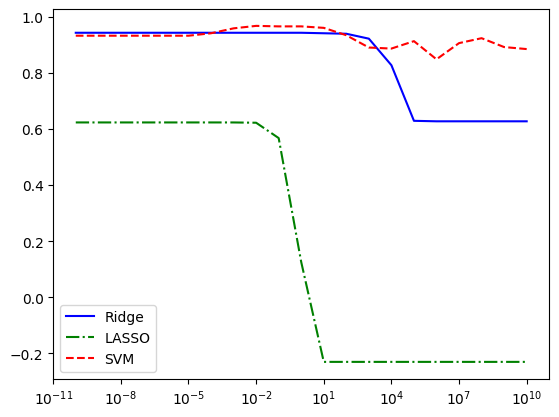

In [18]:
# CODE MANQUANT
#avec la fonction cross_val_score
# Pour charger les classifieurs linéaires de sklearn
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import Lasso
from sklearn.svm import LinearSVC

# Pour charger le module KFold de validation croisée de sklearn
from sklearn.model_selection import KFold
kf = KFold(n_splits=10)
# Pour charger le module cross_val_score
from sklearn.model_selection import cross_val_score

# Definition des paramètres de regularisation
paramRegul = np.logspace(-10,10,21)

# Allocation des variables qui seront utilisées pour sauvegarder le score (Score = Taux de bonne classification = 1 - Taux d'erreur)
vecScoresRidge = []
vecScoresLasso = []
vecScoresSVM = []
for Regul in paramRegul:
    # Pour instancier les classifieurs linéaires de sklearn /!\ avec le paramètre de regularisation /!\
    clfRidge = RidgeClassifier(alpha=Regul)
    clfLasso = Lasso(alpha=Regul)
    clfSVM = LinearSVC(C=Regul)

    # Attention partie un peu "difficile à lire" : on ajoute à la fin du vecteur (avec la méthode 'append' la moyenne 'np.mean()' des scores obtenus par la validation sur 10 plis avec 'cross_val_score()'
    vecScoresRidge.append( np.mean( cross_val_score(clfRidge, X, y, cv=kf.split(X)) ) )
    vecScoresLasso.append( np.mean( cross_val_score(clfLasso, X, y, cv=kf.split(X)) ) )
    vecScoresSVM.append( np.mean( cross_val_score(clfSVM, X, y, cv=kf.split(X)) ) )

plt.figure(1)
plt.semilogx( paramRegul , vecScoresRidge , 'b')
plt.semilogx( paramRegul , vecScoresLasso , '-.g')
plt.semilogx( paramRegul , vecScoresSVM , '--r')
plt.legend(['Ridge' , 'LASSO' , 'SVM'])

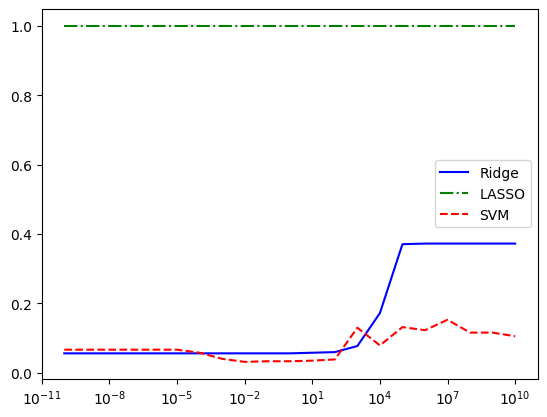

In [19]:
# CODE MANQUANT
# Pour supprimer les messages d'erreurs
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

# Pour charger les classifieurs linéaires de sklearn
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import Lasso
from sklearn.svm import LinearSVC

from sklearn.model_selection import KFold
kf = KFold(n_splits=10)

vecTauxErreurRidge = []
vecTauxErreurLasso = []
vecTauxErreurSVM = []

paramRegul = np.logspace(-10,10,21)
for Regul in paramRegul:
    clfRidge = RidgeClassifier(alpha=Regul)
    clfLasso = Lasso(alpha=Regul)
    clfSVM = LinearSVC(C=Regul)

    NbErreurRidge = 0
    NbErreurLasso = 0
    NbErreurSVM = 0

    kf_splits = kf.split(X)
    for idx_train , idx_test in kf_splits:
    #    print('Taille du jeu de données : Train=' + str(idx_train.shape[0]) + ' / Test=' +str(idx_test.shape[0]) )
        X_train = X[idx_train,:]
        X_test = X[idx_test,:]
        y_train = y[idx_train]
        y_test = y[idx_test]
#        print('Taille du jeu de données : Train=' + str(X_train.shape) + ' / Test=' +str(X_test.shape) )
        clfRidge.fit(X_train, y_train)
        y_ridge = clfRidge.predict(X_test)
        NbErreurRidge += np.sum(y_ridge != y_test)

        clfLasso.fit(X_train, y_train)
        y_lasso = clfLasso.predict(X_test)
        NbErreurLasso += np.sum(y_lasso != y_test)

        clfSVM.fit(X_train, y_train)
        y_svm = clfSVM.predict(X_test)
        NbErreurSVM += np.sum(y_svm != y_test)

    vecTauxErreurRidge.append( np.mean(NbErreurRidge) / y.shape[0] )
    vecTauxErreurLasso.append( np.mean(NbErreurLasso) / y.shape[0] )
    vecTauxErreurSVM.append( np.mean(NbErreurSVM) / y.shape[0] )

plt.figure(1)
plt.semilogx( paramRegul , vecTauxErreurRidge , 'b')
plt.semilogx( paramRegul , vecTauxErreurLasso , '-.g')
plt.semilogx( paramRegul , vecTauxErreurSVM , '--r')
plt.legend(['Ridge' , 'LASSO' , 'SVM'])

## Questions
* **Pour le SVM**, utiliser un noyau (par exemple, Gaussien or RBF) et faire varier **conjoitement** le paramètre du noyau et le paramètre de régularisation

In [20]:
# CODE MANQUANT
from sklearn.model_selection import cross_val_score

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

from sklearn.svm import SVC

from sklearn.model_selection import KFold
kf = KFold(n_splits=10)

matTauxErreurSVM = np.zeros([11,11])
print(matTauxErreurSVM.shape)

idxNoyau=0
idxRegul=0
paramRegul = np.logspace(-10,10,11)
paramNoyau = np.logspace(-10,10,11)
for Noyau in paramNoyau:
    for Regul in paramRegul:
        clfSVM = SVC(kernel='rbf', C=Regul , gamma=Noyau)
        NbErreurSVM = 0

        kf_splits = kf.split(X)
        for idx_train , idx_test in kf_splits:
            X_train = X[idx_train,:]
            X_test = X[idx_test,:]
            y_train = y[idx_train]
            y_test = y[idx_test]

            clfSVM.fit(X_train, y_train)
            y_svm = clfSVM.predict(X_test)
            NbErreurSVM += np.sum(y_svm != y_test)

        matTauxErreurSVM[idxNoyau,idxRegul] = np.mean(NbErreurSVM) / y.shape[0]



(11, 11)


In [21]:
plt.figure(1)

print( matTauxErreurSVM )

[[0.37258348 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        

<Figure size 640x480 with 0 Axes>

## Questions
* **Appliquer les autres méthodes de classification non-linéaires vues en cours** (ANN / MLP & arbre de décision)

In [25]:
# CODE MANQUANT
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

from sklearn.ensemble import RandomForestClassifier
clfForest = RandomForestClassifier(n_estimators = 200, max_depth=10)

from sklearn.neural_network import MLPClassifier
clfAnn = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)

"""from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
clfAnn = Sequential()
clfAnn.add(Dense(units=512, activation='relu'))
clfAnn.add(Dense(units=10, activation='sigmoid'))
optimizer = Adam(learning_rate=0.001)
clfAnn.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])"""

from sklearn.model_selection import KFold
kf = KFold(n_splits=10)
kf_splits = kf.split(X)

#avec la fonction cross_val_score
from sklearn.model_selection import cross_val_score
scoresForest = cross_val_score(clfForest, X, y, cv=kf_splits)
kf_splits = kf.split(X)
scoresAnn = cross_val_score(clfAnn, X, y, cv=kf_splits)

print('Score du classifieur Forest = ' + str(np.mean(scoresForest)))
print('Score du classifieur ANN = ' + str(np.mean(scoresAnn)))

Score du classifieur Forest = 0.9472744360902254
Score du classifieur ANN = 0.9490288220551377
